# InChI Cetane Number Prediction

This notebook loads the `cn_mixtues_inchi.dat` mixture dataset, derives InChI string features, trains regression models (RandomForest and Neural Networks), and predicts cetane number values.

## Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import re
import pickle

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Feature Engineering Functions

In [3]:
def parse_inchi_formula(inchi):
    """Extract element counts from InChI formula section."""
    if not isinstance(inchi, str):
        return {
            'C': 0, 'H': 0, 'O': 0, 'N': 0,
            'S': 0, 'P': 0, 'F': 0,
            'Cl': 0, 'Br': 0, 'I': 0,
            'other': 0,
            'formula_len': 0
        }

    if not inchi.startswith('InChI='):
        return {
            'C': 0, 'H': 0, 'O': 0, 'N': 0,
            'S': 0, 'P': 0, 'F': 0,
            'Cl': 0, 'Br': 0, 'I': 0,
            'other': 0,
            'formula_len': 0
        }

    try:
        formula_part = inchi.split('/')[1]
    except IndexError:
        formula_part = ''

    pattern = re.compile(r'([A-Z][a-z]?)(\d*)')

    counts = {
        'C': 0, 'H': 0, 'O': 0, 'N': 0,
        'S': 0, 'P': 0, 'F': 0,
        'Cl': 0, 'Br': 0, 'I': 0
    }

    other = 0
    for match in pattern.finditer(formula_part):
        element = match.group(1)
        count = int(match.group(2)) if match.group(2) else 1
        if element in counts:
            counts[element] += count
        else:
            other += count

    counts['other'] = other
    counts['formula_len'] = len(formula_part)
    return counts

print("parse_inchi_formula defined")

parse_inchi_formula defined


In [4]:
def extract_inchi_features(inchi):
    """Extract full feature set from InChI (matching notebook approach)."""
    if not isinstance(inchi, str):
        inchi = ''

    counts = parse_inchi_formula(inchi)
    valid = inchi.startswith('InChI=')

    features = {
        'has_inchi': int(valid),
        'string_len': len(inchi),
        'has_stereo': int('/t' in inchi or '/m' in inchi or '/s' in inchi),
        'has_charge': int('/q' in inchi),
        'has_isotope': int('/i' in inchi),
        'has_reconnected': int('/r' in inchi),
    }

    features.update(counts)

    # Heavy atoms
    features['num_heavy_atoms'] = sum(
        counts[e] for e in ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I']
    )

    # Heteroatoms
    features['num_heteroatoms'] = sum(
        counts[e] for e in ['N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I']
    )

    # Ratios
    features['CH_ratio'] = counts['C'] / counts['H'] if counts['H'] > 0 else 0.0
    features['OC_ratio'] = counts['O'] / counts['C'] if counts['C'] > 0 else 0.0

    return features

print("extract_inchi_features defined")

extract_inchi_features defined


In [5]:
def build_feature_matrix(df):
    """Build feature matrix exactly like notebook."""
    inchi_cols = [f'cpnt_inchi_{i}' for i in range(1, 11)]
    vol_cols = [f'cpnt_vol_{i}' for i in range(1, 11)]

    rows = []

    for _, row in df.iterrows():
        # Normalize volumes
        volumes = []
        for col in vol_cols:
            val = row.get(col, 0.0)
            if pd.isna(val):
                val = 0.0
            volumes.append(float(val))

        total_volume = sum(volumes)
        if total_volume == 0:
            total_volume = 1.0

        normalized = [v / total_volume for v in volumes]

        base = {
            # Mixture-level stats
            'mix_total_volume': total_volume,
            'mix_nonzero_components': sum(1 for v in normalized if v > 0),
            'mix_max_volume': max(normalized),
            'mix_min_nonzero_volume': min((v for v in normalized if v > 0), default=0.0),
            'mix_volume_entropy': -sum(v * np.log(v) for v in normalized if v > 0),
        }

        # Component-level features
        for idx, inchi_col in enumerate(inchi_cols, start=1):
            inchi_value = row.get(inchi_col, '')
            comp = extract_inchi_features(inchi_value)
            vol = normalized[idx - 1]

            # Weighted mixture features
            for key, value in comp.items():
                mix_key = f'mix_{key}'
                base[mix_key] = base.get(mix_key, 0.0) + vol * value

            # Individual component features
            base[f'comp_{idx}_C'] = comp['C']
            base[f'comp_{idx}_H'] = comp['H']
            base[f'comp_{idx}_O'] = comp['O']
            base[f'comp_{idx}_N'] = comp['N']
            base[f'comp_{idx}_S'] = comp['S']
            base[f'comp_{idx}_num_heteroatoms'] = comp['num_heteroatoms']

        rows.append(base)

    return pd.DataFrame(rows).fillna(0.0)

print("build_feature_matrix defined")

build_feature_matrix defined


## Load and Prepare Data

In [6]:
# Load dataset
data_path = 'cn_mixtues_inchi.dat'
df = pd.read_csv(data_path, sep='\t')

print('Rows loaded:', len(df))
print('\nColumns:')
print(df.columns.tolist())
print('\nFirst few rows:')
print(df.head())

Rows loaded: 1143

Columns:
['No', 'cpnt_inchi_1', 'cpnt_inchi_2', 'cpnt_inchi_3', 'cpnt_inchi_4', 'cpnt_inchi_5', 'cpnt_inchi_6', 'cpnt_inchi_7', 'cpnt_inchi_8', 'cpnt_inchi_9', 'cpnt_inchi_10', 'cpnt_vol_1', 'cpnt_vol_2', 'cpnt_vol_3', 'cpnt_vol_4', 'cpnt_vol_5', 'cpnt_vol_6', 'cpnt_vol_7', 'cpnt_vol_8', 'cpnt_vol_9', 'cpnt_vol_10', 'CN']

First few rows:
   No                                       cpnt_inchi_1  \
0   4  InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...   
1   5  InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...   
2   6  InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...   
3   7  InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...   
4   8  InChI=1S/C10H22/c1-3-5-7-9-10-8-6-4-2/h3-10H2,...   

                                    cpnt_inchi_2 cpnt_inchi_3 cpnt_inchi_4  \
0       InChI=1S/C7H8/c1-7-5-3-2-4-6-7/h2-6H,1H3          NaN          NaN   
1       InChI=1S/C7H8/c1-7-5-3-2-4-6-7/h2-6H,1H3          NaN          NaN   
2       InChI=1S/C7H8/c1-7-5-3-2-4-6-7/h2-6H,

In [7]:
# Build features
X = build_feature_matrix(df)

# Target column
y = df['CN'].astype(float)

print('\nFeature matrix shape:', X.shape)
print('Target range:', y.min(), '-', y.max())
print('\nFirst rows of features:')
print(X.head())


Feature matrix shape: (1143, 87)
Target range: 0.0 - 131.02

First rows of features:
   mix_total_volume  mix_nonzero_components  mix_max_volume  \
0               1.0                       2           0.796   
1               1.0                       2           0.592   
2               1.0                       2           0.804   
3               1.0                       2           0.602   
4               1.0                       2           0.807   

   mix_min_nonzero_volume  mix_volume_entropy  mix_has_inchi  mix_string_len  \
0                   0.204            0.505898            1.0          48.756   
1                   0.408            0.676122            1.0          46.512   
2                   0.196            0.494807            1.0          42.156   
3                   0.398            0.672192            1.0          44.378   
4                   0.193            0.490544            1.0          49.842   

   mix_has_stereo  mix_has_charge  mix_has_isotope  ..

In [8]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f'Train set: {len(X_train)} samples')
print(f'Test set: {len(X_test)} samples')

Train set: 914 samples
Test set: 229 samples


## Train Random Forest Model

In [9]:
# Train Random Forest
model = RandomForestRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1
)

print('Training RandomForest with 250 estimators...')
model.fit(X_train, y_train)
print('Training complete!')

Training RandomForest with 250 estimators...
Training complete!


In [10]:
# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Metrics
print('\n' + '='*50)
print('RANDOMFOREST MODEL PERFORMANCE')
print('='*50)

print('\nTrain MAE:', mean_absolute_error(y_train, train_pred))
print('Train R2:', r2_score(y_train, train_pred))

print('\nTest MAE:', mean_absolute_error(y_test, test_pred))
print('Test R2:', r2_score(y_test, test_pred))


RANDOMFOREST MODEL PERFORMANCE

Train MAE: 3.2044776342631938
Train R2: 0.9335200530620509

Test MAE: 7.299959340264783
Test R2: 0.6198925657119134


In [11]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print('\n' + '='*50)
print('TOP 20 FEATURES')
print('='*50)
print(importance_df.head(20))


TOP 20 FEATURES
                   feature  importance
12                   mix_H    0.337243
25            mix_CH_ratio    0.108819
6           mix_string_len    0.107132
26            mix_OC_ratio    0.069972
27                comp_1_C    0.044478
23     mix_num_heavy_atoms    0.039936
2           mix_max_volume    0.035003
28                comp_1_H    0.032833
11                   mix_C    0.029502
22         mix_formula_len    0.029457
3   mix_min_nonzero_volume    0.020512
4       mix_volume_entropy    0.020395
13                   mix_O    0.019031
24     mix_num_heteroatoms    0.016424
34                comp_2_H    0.014561
33                comp_2_C    0.014443
29                comp_1_O    0.011374
32  comp_1_num_heteroatoms    0.011172
38  comp_2_num_heteroatoms    0.009876
35                comp_2_O    0.009443


## Export Models to ONNX Format

In [12]:
# Export RandomForest to ONNX
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnx
    
    # Define input
    initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]
    
    # Convert
    onnx_model = convert_sklearn(model, initial_types=initial_type)
    
    # Save
    with open('inchi_cn_model.onnx', 'wb') as f:
        f.write(onnx_model.SerializeToString())
    
    print('✓ RandomForest exported to inchi_cn_model.onnx')
except ImportError:
    print('⚠ skl2onnx not installed. Install with: pip install skl2onnx onnx')

✓ RandomForest exported to inchi_cn_model.onnx


## Visualization

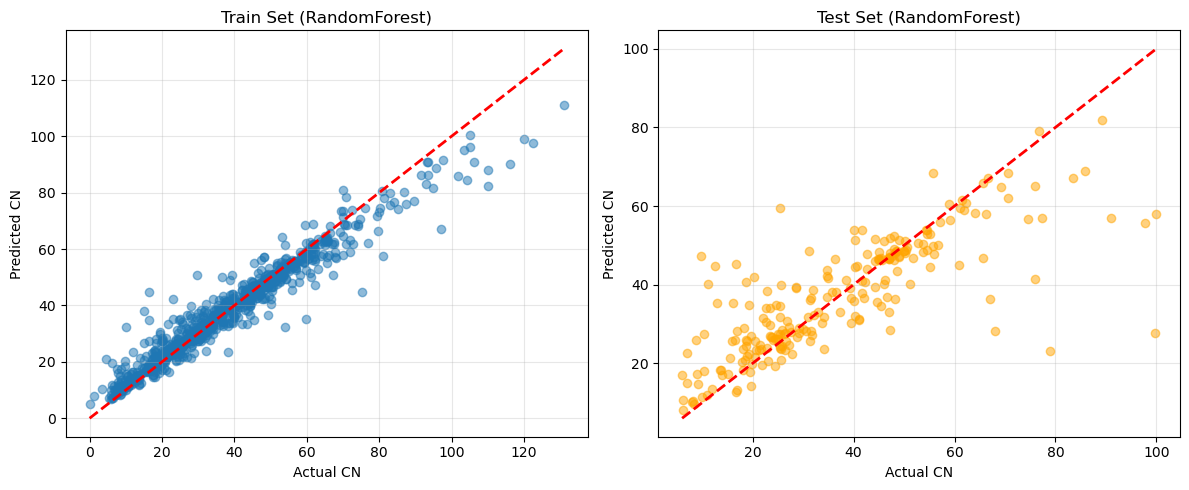

Plot saved as rf_predictions.png


In [13]:
# Plot predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
axes[0].scatter(y_train, train_pred, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual CN')
axes[0].set_ylabel('Predicted CN')
axes[0].set_title('Train Set (RandomForest)')
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test, test_pred, alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual CN')
axes[1].set_ylabel('Predicted CN')
axes[1].set_title('Test Set (RandomForest)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print('Plot saved as rf_predictions.png')

## Save Models and Data

In [14]:
# Save pickle model
with open('inchi_cn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('✓ RandomForest model saved to inchi_cn_model.pkl')

# Save predictions
results_df = pd.DataFrame({
    'actual_cn': y_test.values,
    'predicted_cn': test_pred,
    'error': np.abs(y_test.values - test_pred)
})

results_df.to_csv('inchi_cn_predictions.csv', index=False)
print('✓ Predictions saved to inchi_cn_predictions.csv')

# Save feature importance
importance_df.to_csv('rf_feature_importance.csv', index=False)
print('✓ Feature importance saved to rf_feature_importance.csv')

✓ RandomForest model saved to inchi_cn_model.pkl
✓ Predictions saved to inchi_cn_predictions.csv
✓ Feature importance saved to rf_feature_importance.csv


# InChI Cetane Number Prediction

This notebook loads the `cn_mixtues_inchi.dat` mixture dataset, derives InChI string features, trains a regression model, and predicts cetane number values.

In [15]:
import pandas as pd
import numpy as np
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# Parse molecular formula from InChI
# ---------------------------------------------------------
def parse_inchi_formula(inchi):

    # Handle missing / invalid values
    if not isinstance(inchi, str):
        return {
            'C': 0, 'H': 0, 'O': 0, 'N': 0,
            'S': 0, 'P': 0, 'F': 0,
            'Cl': 0, 'Br': 0, 'I': 0,
            'other': 0,
            'formula_len': 0
        }

    if not inchi.startswith('InChI='):
        return {
            'C': 0, 'H': 0, 'O': 0, 'N': 0,
            'S': 0, 'P': 0, 'F': 0,
            'Cl': 0, 'Br': 0, 'I': 0,
            'other': 0,
            'formula_len': 0
        }

    # Extract formula section
    try:
        formula_part = inchi.split('/')[1]
    except IndexError:
        formula_part = ''

    # Regex for chemical elements
    pattern = re.compile(r'([A-Z][a-z]?)(\d*)')

    counts = {
        'C': 0,
        'H': 0,
        'O': 0,
        'N': 0,
        'S': 0,
        'P': 0,
        'F': 0,
        'Cl': 0,
        'Br': 0,
        'I': 0
    }

    other = 0

    for match in pattern.finditer(formula_part):

        element = match.group(1)

        count = int(match.group(2)) if match.group(2) else 1

        if element in counts:
            counts[element] += count
        else:
            other += count

    counts['other'] = other
    counts['formula_len'] = len(formula_part)

    return counts


# ---------------------------------------------------------
# Extract features from InChI
# ---------------------------------------------------------
def extract_inchi_features(inchi):

    # Convert NaN/float/etc to empty string
    if not isinstance(inchi, str):
        inchi = ''

    counts = parse_inchi_formula(inchi)

    valid = inchi.startswith('InChI=')

    features = {
        'has_inchi': int(valid),
        'string_len': len(inchi),

        'has_stereo': int(
            '/t' in inchi or
            '/m' in inchi or
            '/s' in inchi
        ),

        'has_charge': int('/q' in inchi),
        'has_isotope': int('/i' in inchi),
        'has_reconnected': int('/r' in inchi),
    }

    features.update(counts)

    # Heavy atoms
    features['num_heavy_atoms'] = sum(
        counts[e]
        for e in ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I']
    )

    # Heteroatoms
    features['num_heteroatoms'] = sum(
        counts[e]
        for e in ['N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I']
    )

    # Ratios
    features['CH_ratio'] = (
        counts['C'] / counts['H']
        if counts['H'] > 0 else 0.0
    )

    features['OC_ratio'] = (
        counts['O'] / counts['C']
        if counts['C'] > 0 else 0.0
    )

    return features


# ---------------------------------------------------------
# Build ML feature matrix
# ---------------------------------------------------------
def build_feature_matrix(df):

    inchi_cols = [f'cpnt_inchi_{i}' for i in range(1, 11)]
    vol_cols = [f'cpnt_vol_{i}' for i in range(1, 11)]

    rows = []

    for _, row in df.iterrows():

        # Safe volume extraction
        volumes = []

        for col in vol_cols:

            val = row.get(col, 0.0)

            if pd.isna(val):
                val = 0.0

            volumes.append(float(val))

        total_volume = sum(volumes)

        if total_volume == 0:
            total_volume = 1.0

        normalized = [v / total_volume for v in volumes]

        base = {

            # Mixture-level stats
            'mix_total_volume': total_volume,

            'mix_nonzero_components':
                sum(1 for v in normalized if v > 0),

            'mix_max_volume':
                max(normalized),

            'mix_min_nonzero_volume':
                min((v for v in normalized if v > 0), default=0.0),

            'mix_volume_entropy':
                -sum(v * np.log(v) for v in normalized if v > 0),
        }

        # Component-level features
        for idx, inchi_col in enumerate(inchi_cols, start=1):

            inchi_value = row.get(inchi_col, '')

            comp = extract_inchi_features(inchi_value)

            vol = normalized[idx - 1]

            # Weighted mixture features
            for key, value in comp.items():

                mix_key = f'mix_{key}'

                base[mix_key] = base.get(mix_key, 0.0) + vol * value

            # Individual component features
            base[f'comp_{idx}_C'] = comp['C']
            base[f'comp_{idx}_H'] = comp['H']
            base[f'comp_{idx}_O'] = comp['O']
            base[f'comp_{idx}_N'] = comp['N']
            base[f'comp_{idx}_S'] = comp['S']

            base[f'comp_{idx}_num_heteroatoms'] = \
                comp['num_heteroatoms']

        rows.append(base)

    return pd.DataFrame(rows).fillna(0.0)


# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
data_path = 'cn_mixtues_inchi.dat'

df = pd.read_csv(data_path, sep='\t')

print('Rows loaded:', len(df))

print('\nColumns:')
print(df.columns.tolist())


# ---------------------------------------------------------
# Build features
# ---------------------------------------------------------
X = build_feature_matrix(df)

# Target column
y = df['CN'].astype(float)

print('\nFeature matrix shape:', X.shape)

print('\nFirst rows of features:')
print(X.head())


# ---------------------------------------------------------
# Train / test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------------------------
# Train Random Forest
# ---------------------------------------------------------
model = RandomForestRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------
train_pred = model.predict(X_train)

test_pred = model.predict(X_test)


# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------
print('\n==============================')
print('MODEL PERFORMANCE')
print('==============================')

print('\nTrain MAE:')
print(mean_absolute_error(y_train, train_pred))

print('\nTrain R2:')
print(r2_score(y_train, train_pred))

print('\nTest MAE:')
print(mean_absolute_error(y_test, test_pred))

print('\nTest R2:')
print(r2_score(y_test, test_pred))


# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print('\n==============================')
print('TOP 20 FEATURES')
print('==============================')

print(importance_df.head(20))

Rows loaded: 1143

Columns:
['No', 'cpnt_inchi_1', 'cpnt_inchi_2', 'cpnt_inchi_3', 'cpnt_inchi_4', 'cpnt_inchi_5', 'cpnt_inchi_6', 'cpnt_inchi_7', 'cpnt_inchi_8', 'cpnt_inchi_9', 'cpnt_inchi_10', 'cpnt_vol_1', 'cpnt_vol_2', 'cpnt_vol_3', 'cpnt_vol_4', 'cpnt_vol_5', 'cpnt_vol_6', 'cpnt_vol_7', 'cpnt_vol_8', 'cpnt_vol_9', 'cpnt_vol_10', 'CN']

Feature matrix shape: (1143, 87)

First rows of features:
   mix_total_volume  mix_nonzero_components  mix_max_volume  \
0               1.0                       2           0.796   
1               1.0                       2           0.592   
2               1.0                       2           0.804   
3               1.0                       2           0.602   
4               1.0                       2           0.807   

   mix_min_nonzero_volume  mix_volume_entropy  mix_has_inchi  mix_string_len  \
0                   0.204            0.505898            1.0          48.756   
1                   0.408            0.676122            1.